**Ch121a | Module 3: Periodic DFT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module3_Periodic-DFT/notebooks/02_planewaves_pseudopotentials_kpoints.ipynb)

# Notebook 2: Plane-waves, Pseudopotentials & k-points

---

## Learning Objectives

- Plane-wave basis set and the role of ENCUT
- Core vs. valence electron distinction and and pseudopotentials
- PAW, USPP, and NCpp schemes 
- k-point sampling and Monkhorst-Pack grids
- Smearing methods (ISMEAR/SIGMA)
- DFT+U (Hubbard correction) 
- van der Waals correction schemes 
- Visual comparison of localized basis functions and plane-wave basis behavior


## 1. Plane-wave Basis Set and ENCUT

In periodic DFT, the cell-periodic part of the Bloch wavefunction is expanded in plane waves:

$$u_{n\mathbf{k}}(\mathbf{r}) = \sum_{\mathbf{G}} c_{n\mathbf{k}+\mathbf{G}} \, e^{i\mathbf{G}\cdot\mathbf{r}}$$

where **G** are reciprocal lattice vectors. The basis is truncated by the **kinetic energy cutoff**:

$$\frac{\hbar^2}{2m} |\mathbf{k} + \mathbf{G}|^2 \leq E_{\text{cut}} \quad (\text{ENCUT in VASP, eV})$$

### Why plane waves?

- Complete, unbiased — no BSSE (basis set superposition error)
- Easy to compute forces: Hellmann-Feynman theorem is exact
- Convergence controlled by a single parameter: **ENCUT**
- Fourier transforms (FFTs) make the cost manageable

### ENCUT Convergence

A proper calculation requires checking that total energies and forces are converged with respect to ENCUT:

| Element / system | Typical ENCUT (eV) | Recommended |
|---|---|---|
| Light elements (H, C, N, O) | 400–520 | 500 |
| Si, Ge | 245–400 | 400 |
| Transition metals (Ti, Fe, Co) | 400–600 | 520 |
| F, O-containing oxides | 520–600 | 600 |

**Rule of thumb**: start at 1.3× the ENMAX from the POTCAR file; test convergence by doubling to 2×ENMAX. Cost to accuracy ratio is also important. 

### Plane waves vs STO/GTO basis sets

In molecular quantum chemistry, one usually expands orbitals in **localized atom-centered basis functions**:

- **STO (Slater-type orbitals):** physically good near nuclei and at long range, but expensive for integral evaluation.
- **GTO (Gaussian-type orbitals):** computationally efficient (analytic integrals), so they became the standard in molecular packages.

For periodic solids, **plane waves (PW)** are usually preferred:

| Basis type | Typical use | Strengths | Limitations |
|---|---|---|---|
| STO | Historical/atomic and some molecular methods | Correct cusp/asymptotics | Expensive integrals; uncommon in modern periodic workflows |
| GTO | Molecular QC (finite systems) | Compact for isolated molecules; many mature basis families | Basis-set superposition error; basis depends on atomic positions; periodic implementations are less straightforward |
| Plane waves | Periodic DFT (solids, surfaces, 2D) | Uniform, unbiased basis; simple systematic convergence via ENCUT; naturally compatible with PBC + FFTs | Needs pseudopotentials/PAW and larger basis size for vacuum-heavy cells |

Why PWs are especially important in periodic DFT:

1. **Natural match to Bloch-periodic boundary conditions**
2. **Single convergence knob (ENCUT)** simplifies reproducibility across materials
3. **Efficient large-scale implementations** with FFTs and parallel k-point/band distribution
4. **Robust forces and stress** for structure optimization and molecular dynamics in solids/surfaces


### Visual comparison: localized basis functions vs plane waves (schematic)

The figure below gives two complementary comparisons:

1. **Real-space picture:** a localized Gaussian-like orbital (GTO-like behavior) versus a delocalized plane wave.
2. **Reciprocal-space picture:** plane-wave basis truncation by a spherical cutoff \(|\mathbf{k}+\mathbf{G}|^2 \le E_{cut}\), where increasing ENCUT includes more \(\mathbf{G}\)-vectors.

These schematics help explain why plane waves are naturally suited to periodic systems while localized bases are compact for molecules.


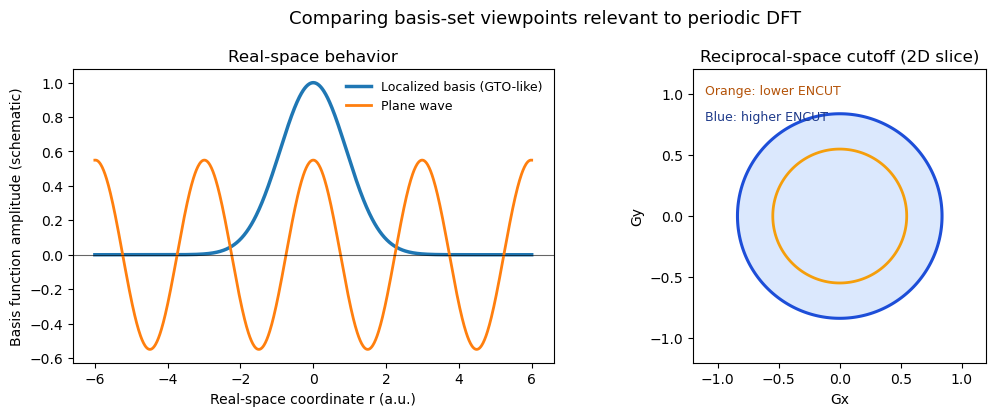

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 900)
gto_like = np.exp(-0.6 * x**2)
plane_wave = 0.55 * np.cos(2.1 * x)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) Real-space basis shape comparison
axs[0].plot(x, gto_like, lw=2.5, label='Localized basis (GTO-like)')
axs[0].plot(x, plane_wave, lw=2.0, label='Plane wave')
axs[0].axhline(0.0, color='k', lw=0.8, alpha=0.6)
axs[0].set_xlabel('Real-space coordinate r (a.u.)')
axs[0].set_ylabel('Basis function amplitude (schematic)')
axs[0].set_title('Real-space behavior')
axs[0].legend(frameon=False, fontsize=9)

# (b) Reciprocal-space cutoff sphere (2D slice)
g = np.linspace(-1.2, 1.2, 300)
GX, GY = np.meshgrid(g, g)
R2 = GX**2 + GY**2

ecut_low = 0.30
ecut_high = 0.70

axs[1].contourf(GX, GY, (R2 <= ecut_high).astype(float), levels=[-0.1, 0.1, 1.1], alpha=0.18, colors=['white', '#3b82f6'])
axs[1].contour(GX, GY, R2, levels=[ecut_low, ecut_high], colors=['#f59e0b', '#1d4ed8'], linewidths=[2.0, 2.2])
axs[1].set_aspect('equal', adjustable='box')
axs[1].set_xlabel('Gx')
axs[1].set_ylabel('Gy')
axs[1].set_title('Reciprocal-space cutoff (2D slice)')
axs[1].text(0.04, 0.95, 'Orange: lower ENCUT', transform=axs[1].transAxes, va='top', fontsize=9, color='#b45309')
axs[1].text(0.04, 0.86, 'Blue: higher ENCUT', transform=axs[1].transAxes, va='top', fontsize=9, color='#1e3a8a')

fig.suptitle('Comparing basis-set viewpoints relevant to periodic DFT', fontsize=13)
fig.tight_layout()
plt.show()


## 2. Core vs. Valence Electrons and Pseudopotentials

All-electron DFT calculations include every electron of every atom. For heavy elements, this is prohibitively expensive. The **frozen-core approximation** separates:

- **Core electrons**: tightly bound, chemically inert, do not participate in bonding
- **Valence electrons**: form bonds, dominate chemistry

A **pseudopotential (PP)** replaces the all-electron potential for the core region with a smooth effective potential that reproduces the correct valence wavefunction and energy outside a cutoff radius $r_c$.

### PAW vs. USPP vs. NCpp

| Scheme | Full name | Key feature | VASP recommendation |
|---|---|---|---|
| **PAW** | Projector Augmented Wave | Recovers all-electron density near nuclei | ✅ Default, always use |
| **USPP** | Ultra-soft Pseudopotential | Low ENCUT, less accurate | ⚠ Use only if PAW unavailable |
| **NCpp** | Norm-conserving PP | Stricter norm conservation | Used in QE/Abinit, high ENCUT |

**Always use PAW potentials in VASP.** They provide near all-electron accuracy at pseudopotential cost.

### Core electrons included in VASP PAW (examples)

| Element | Core | Valence | POTCAR name |
|---|---|---|---|
| Si | [Ne] | 3s²3p² | PAW_PBE Si |
| Ti | [Ar] | 3d²4s² | PAW_PBE Ti_sv (includes 3s,3p in valence) |
| O | [He] | 2s²2p⁴ | PAW_PBE O |
| Fe | [Ne] | 3d⁶4s² | PAW_PBE Fe_pv (3p in valence) |

## 3. k-point Sampling

The **k-point integral** (sum over the BZ) appears in every observable:

$$\langle A \rangle = \frac{V_{\text{cell}}}{(2\pi)^3} \int_{\text{BZ}} A(\mathbf{k}) \, d\mathbf{k} \approx \sum_{\mathbf{k}_i} w_i \, A(\mathbf{k}_i)$$

A **Monkhorst-Pack (MP) grid** generates a uniform mesh of k-points:

```
K-Points
0
Monkhorst-Pack
  8  8  8      ! 8×8×8 mesh → 512 k-points in full BZ
  0  0  0      ! Γ-centered (shift = 0 0 0)
```

### k-mesh vs. system type

| System | Recommended mesh | Notes |
|---|---|---|
| Metal | 12×12×12 or denser | Dense mesh for sharp Fermi surface |
| Semiconductor | 6×6×6 to 8×8×8 | Moderate mesh sufficient |
| Insulator | 4×4×4 to 6×6×6 | Sparser mesh converges quickly |
| Surface slab | 6×6×1 | Only 1 k-point in z (non-periodic) |
| 2D material | 12×12×1 | Dense in-plane |
| Molecule in box | 1×1×1 (Γ only) | Isolated system |
**Sometimes, a simple rule, like _25/l or 40/l_ can be used to derive the desired number of kpoints in a direction, where _l_ is the cell vector.** 

_E.g., for Si unit cell (a = b = c = 5.43 Å), 5x5x5 kpoints would be good for a low-level calculations, while 8x8x8 would be recommended for precise electronic structure computation. Considering the timescales to finish some calculations within classtime, we will often use way less (even 10/l or 15.l) than recommended number of kpoints to obtain low quality, qualitative results._  

### Smearing (ISMEAR and SIGMA)

Smearing broadens the Fermi-Dirac step to improve convergence:

| ISMEAR | Method | Use for |
|---|---|---|
| -5 | Tetrahedron (Blöchl) | **Best for DOS, insulators, semiconductors** |
| 0 | Gaussian | Molecules, insulators, final SCF |
| 1, 2 | Methfessel-Paxton 1st, 2nd order | **Metals** (fast convergence) |
| -1 | Fermi-Dirac | Finite-temperature metals |

**Rule**: use ISMEAR=1 (MP) with SIGMA=0.2 for metals during relaxation; switch to ISMEAR=-5 for DOS.  
For semiconductors/insulators: ISMEAR=0, SIGMA=0.05.

### Comparison with including pseudopotentials
![Pseudopotential](../tmp/sample/PAW_pp.png)

## 4. DFT+U (Hubbard Correction)

Standard GGA/LDA under-localizes *d* and *f* electrons in transition metal compounds, causing wrong band gaps and magnetic moments. The **DFT+U (Hubbard)** correction adds an on-site Coulomb term:

$$E_{DFT+U} = E_{DFT} + \frac{U_{eff}}{2} \sum_{I,\sigma} \text{Tr}[\hat{n}^{I\sigma}(1 - \hat{n}^{I\sigma})]$$

where $U_{eff} = U - J$ (Dudarev formulation, `LDAUTYPE=2`).

### VASP DFT+U tags

```
LDAU     = .TRUE.
LDAUTYPE = 2          ! Dudarev: U_eff = U - J
LDAUL    = 2 -1       ! l=2 (d electrons) for TM; -1 (none) for O
LDAUU    = 4.0 0.0    ! U_eff for TM (eV); 0 for O
LDAUJ    = 0.0 0.0    ! J = 0 in Dudarev scheme
LMAXMIX  = 4          ! Required for d electrons (6 for f)
```

### Typical U values

| System | U_eff (eV) | Reference |
|---|---|---|
| NiO (Ni 3d) | 6.2 | [Dudarev et al., PRB 1998](https://doi.org/10.1103/PhysRevB.57.1505) |
| CeO₂ (Ce 4f) | 1.5–5 | [Loschen et al., PRB 2007](https://doi.org/10.1103/PhysRevB.75.035115) |
| 3d Metal oxides | -- --  | [Wang et al., PRB 2006](https://doi.org/10.1103/PhysRevB.73.195107) |


## 5. van der Waals Corrections

Standard GGA misses long-range dispersion (van der Waals) interactions. Essential for layered materials, molecular adsorption, and soft matter.

| Tag (IVDW) | Scheme | When to use |
|---|---|---|
| 11 | DFT-D3 (Grimme, zero-damping) | Most solids, surfaces |
| 12 | DFT-D3 (Grimme, BJ-damping) | Better for molecular systems |
| 20 | TS (Tkatchenko-Scheffler) | Molecules on metal surfaces |
| 202 | MBD (many-body dispersion) | Layered / molecular crystals |
| — | optB86b-vdW, rVV10 | Set via GGA= in INCAR; used for water, layered 2D |

**Recommendation**: use `IVDW=12` (D3-BJ) as a safe default for solids and surfaces.

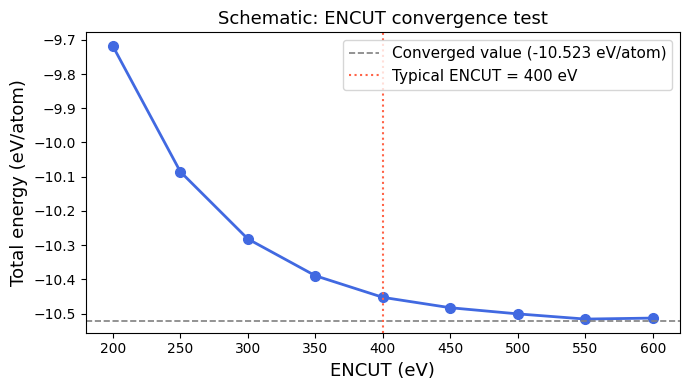

Energy is well-converged by ENCUT ≈ 400 eV for most sp elements.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# Schematic ENCUT convergence — total energy vs. cutoff
encuts = np.array([200, 250, 300, 350, 400, 450, 500, 550, 600])
# Energy converges asymptotically; add small noise
e_ref = -10.523   # converged energy (arbitrary, eV/atom)
decay = 0.8 * np.exp(-0.012 * (encuts - 200))
noise = np.random.normal(0, 0.003, len(encuts))
energies = e_ref + decay + noise

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(encuts, energies, 'o-', color='royalblue', lw=2, ms=7)
ax.axhline(e_ref, color='gray', ls='--', lw=1.2, label=f'Converged value ({e_ref} eV/atom)')
ax.axvline(400, color='tomato', ls=':', lw=1.5, label='Typical ENCUT = 400 eV')
ax.set_xlabel('ENCUT (eV)', fontsize=13)
ax.set_ylabel('Total energy (eV/atom)', fontsize=13)
ax.set_title('Schematic: ENCUT convergence test', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("Energy is well-converged by ENCUT ≈ 400 eV for most sp elements.")

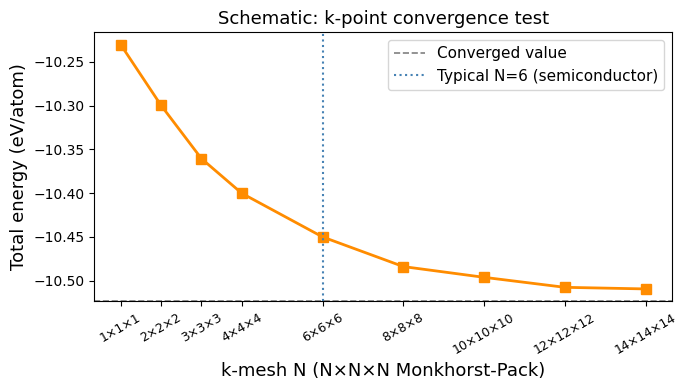

For a semiconductor, a 6×6×6 mesh typically converges total energy to < 1 meV/atom.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13)

# Schematic k-point convergence — total energy vs. k-mesh density
kmesh = np.array([1, 2, 3, 4, 6, 8, 10, 12, 14])  # NxNxN grid
e_ref_k = -10.523
decay_k = 0.4 * np.exp(-0.3 * kmesh)
noise_k = np.random.normal(0, 0.005, len(kmesh))
energies_k = e_ref_k + decay_k + noise_k

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kmesh, energies_k, 's-', color='darkorange', lw=2, ms=7)
ax.axhline(e_ref_k, color='gray', ls='--', lw=1.2, label=f'Converged value')
ax.axvline(6, color='steelblue', ls=':', lw=1.5, label='Typical N=6 (semiconductor)')
ax.set_xlabel('k-mesh N (N×N×N Monkhorst-Pack)', fontsize=13)
ax.set_ylabel('Total energy (eV/atom)', fontsize=13)
ax.set_title('Schematic: k-point convergence test', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(kmesh)
ax.set_xticklabels([f'{n}×{n}×{n}' for n in kmesh], rotation=30, fontsize=9)
plt.tight_layout()
plt.show()
print("For a semiconductor, a 6×6×6 mesh typically converges total energy to < 1 meV/atom.")

## Materials project
[Legacy](https://legacy.materialsproject.org) and [next-gen versions](https://next-gen.materialsproject.org)

## 6. Further Reading

- Payne et al., *Rev. Mod. Phys.* **64**, 1045 (1992) — plane-wave DFT review
- Blöchl, P. E., *Phys. Rev. B* **50**, 17953 (1994) — PAW method
- Monkhorst & Pack, *Phys. Rev. B* **13**, 5188 (1976) — MP k-point grids
- Methfessel & Paxton, *Phys. Rev. B* **40**, 3616 (1989) — MP smearing
- Dudarev et al., *Phys. Rev. B* **57**, 1505 (1998) — DFT+U Dudarev formulation
- Grimme et al., *J. Comput. Chem.* **32**, 1456 (2011) — DFT-D3
- [VASP Wiki: ENCUT](https://www.vasp.at/wiki/index.php/ENCUT)
- [VASP Wiki: ISMEAR](https://www.vasp.at/wiki/index.php/ISMEAR)

---
*Ch121a | Caltech | Module 3 — Notebook 2 of 6*